In [6]:
import torch
import torchvision
from torchvision.transforms import ToTensor, Normalize, Compose
from torchvision.datasets import MNIST

mnist = MNIST(root='data',
             train=True,
             download=True,
             transform=Compose([ToTensor(), Normalize(mean=(0.5,), std=(0.5,))]))

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.97MB/s]


In [7]:
img, label = mnist[0]
print('Label: ', label)
print(img[:,10:15,10:15])
torch.min(img), torch.max(img)

Label:  5
tensor([[[-0.9922,  0.2078,  0.9843, -0.2941, -1.0000],
         [-1.0000,  0.0902,  0.9843,  0.4902, -0.9843],
         [-1.0000, -0.9137,  0.4902,  0.9843, -0.4510],
         [-1.0000, -1.0000, -0.7255,  0.8902,  0.7647],
         [-1.0000, -1.0000, -1.0000, -0.3647,  0.8824]]])


(tensor(-1.), tensor(1.))

In [8]:
def denorm(x):
    out = (x + 1) / 2
    return out.clamp(0, 1)

Label: 5


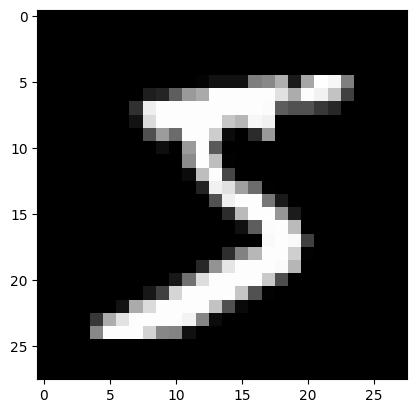

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

img_norm = denorm(img)
plt.imshow(img_norm[0], cmap='gray')
print('Label:', label)

In [10]:
from torch.utils.data import DataLoader

batch_size = 100
data_loader = DataLoader(mnist, batch_size, shuffle=True)

first batch
torch.Size([100, 1, 28, 28])
tensor([6, 9, 3, 6, 0, 0, 8, 0, 0, 7, 3, 8, 7, 5, 3, 2, 2, 3, 4, 3, 0, 6, 8, 4,
        2, 8, 5, 0, 9, 2, 7, 0, 4, 0, 2, 3, 9, 8, 4, 6, 9, 8, 5, 9, 5, 1, 2, 2,
        2, 7, 1, 3, 9, 6, 0, 7, 0, 4, 7, 9, 5, 6, 7, 7, 1, 8, 3, 2, 9, 4, 0, 8,
        6, 5, 3, 6, 2, 6, 6, 1, 5, 6, 5, 8, 6, 6, 5, 9, 8, 8, 0, 0, 5, 4, 0, 6,
        6, 3, 2, 6])


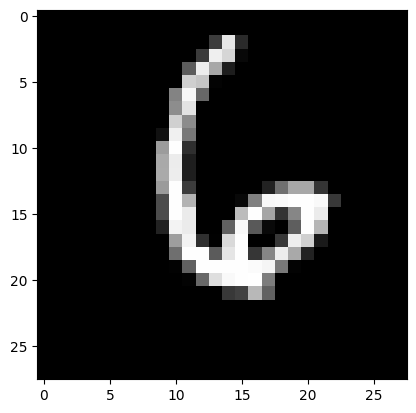

In [11]:
for img_batch, label_batch in data_loader:
    print('first batch')
    print(img_batch.shape)
    plt.imshow(img_batch[0][0], cmap='gray')
    print(label_batch)
    break

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
image_size = 784
hidden_size = 256

In [14]:
import torch.nn as nn

D = nn.Sequential(
    nn.Linear(image_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, hidden_size),
    nn.Linear(hidden_size, 1),
    nn.Sigmoid())

In [15]:
D.to(device);

In [16]:
latent_size = 64

In [17]:
G = nn.Sequential(
    nn.Linear(latent_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, image_size),
    nn.Tanh())

In [18]:
y = G(torch.randn(2, latent_size))
y.reshape(-1, 28,28).shape

torch.Size([2, 28, 28])

In [19]:
y = G(torch.randn(2, latent_size))
gen_imgs = denorm(y.reshape((-1, 28,28)).detach())

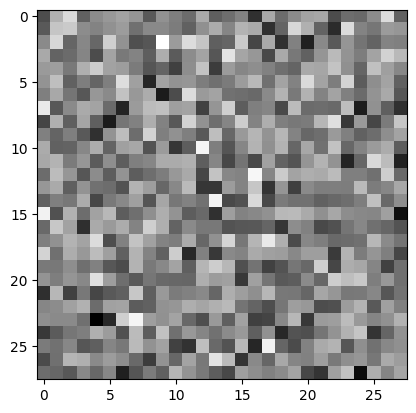

In [20]:
plt.imshow(gen_imgs[0], cmap='gray');

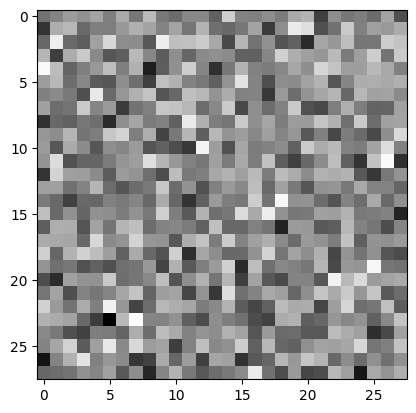

In [21]:
plt.imshow(gen_imgs[1], cmap='gray')

In [22]:
G.to(device)

Sequential(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=784, bias=True)
  (5): Tanh()
)

In [23]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)

In [24]:
def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

def train_discriminator(images):
    # Create the labels which are later used as input for the BCE loss
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Loss for real images
    outputs = D(images)
    d_loss_real = criterion(outputs, real_labels)
    real_score = outputs

    # Loss for fake images
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    outputs = D(fake_images)
    d_loss_fake = criterion(outputs, fake_labels)
    fake_score = outputs

    # Combine losses
    d_loss = d_loss_real + d_loss_fake
    # Reset gradients
    reset_grad()
    # Compute gradients
    d_loss.backward()
    # Adjust the parameters using backprop
    d_optimizer.step()

    return d_loss, real_score, fake_score

In [25]:
def train_generator():
    # Generate fake images and calculate loss
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    labels = torch.ones(batch_size, 1).to(device)
    g_loss = criterion(D(fake_images), labels)

    # Backprop and optimize
    reset_grad()
    g_loss.backward()
    g_optimizer.step()
    return g_loss, fake_images

In [26]:
import os

sample_dir = 'samples'
if not os.path.exists(sample_dir):
    os.makedirs(sample_dir)

In [27]:
! pip install Ipython

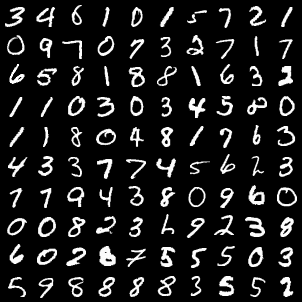

In [28]:
from IPython.display import Image
from torchvision.utils import save_image

# Save some real image
for images, _ in data_loader:
    images = images.reshape(images.size(0), 1, 28, 28)
    save_image(denorm(images), os.path.join(sample_dir, 'real_images.png'), nrow=10)
    break

Image(os.path.join(sample_dir, 'real_images.png'))

Saving fake_images-0000.png


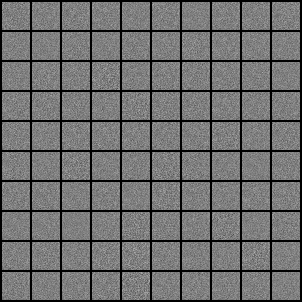

In [29]:
sample_vectors = torch.randn(batch_size, latent_size).to(device)

def save_fake_images(index):
    fake_images = G(sample_vectors)
    fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
    fake_fname = 'fake_images-{0:0=4d}.png'.format(index)
    print('Saving', fake_fname)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=10)

# Before training
save_fake_images(0)
Image(os.path.join(sample_dir, 'fake_images-0000.png'))

In [30]:
%%time

num_epochs = 50
total_step = len(data_loader)
d_losses, g_losses, real_scores, fake_scores = [], [], [], []

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        # Load a batch & transforms to vector
        images = images.reshape(batch_size, -1).to(device)
    
        # Train the discriminator and generator
        d_loss, real_score, fake_score = train_discriminator(images)
        g_loss, fake_images = train_generator()
    
        # Inspect the losses
        if (i+1) % 200 == 0:
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
            real_scores.append(real_score.mean().item())
            fake_scores.append(fake_score.mean().item())
            print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f},g_loss: {:.4f}, D(x): {:.2f},'
                 .format(epoch, num_epochs, i+1, total_step, d_loss.item(), g_loss.item(),
                        real_score.mean().item(), fake_score.mean().item()))

    # Sample and save images
    save_fake_images(epoch+1)

Epoch [0/50], Step [200/600], d_loss: 0.0641,g_loss: 4.4522, D(x): 0.99,
Epoch [0/50], Step [400/600], d_loss: 0.0242,g_loss: 6.6953, D(x): 0.99,
Epoch [0/50], Step [600/600], d_loss: 0.0439,g_loss: 5.5764, D(x): 0.98,
Saving fake_images-0001.png
Epoch [1/50], Step [200/600], d_loss: 0.0557,g_loss: 4.2553, D(x): 0.99,
Epoch [1/50], Step [400/600], d_loss: 0.3258,g_loss: 4.1244, D(x): 0.96,
Epoch [1/50], Step [600/600], d_loss: 0.1015,g_loss: 6.2925, D(x): 0.97,
Saving fake_images-0002.png
Epoch [2/50], Step [200/600], d_loss: 0.0519,g_loss: 5.5383, D(x): 0.97,
Epoch [2/50], Step [400/600], d_loss: 1.1232,g_loss: 4.5995, D(x): 0.83,
Epoch [2/50], Step [600/600], d_loss: 0.6254,g_loss: 4.0225, D(x): 0.78,
Saving fake_images-0003.png
Epoch [3/50], Step [200/600], d_loss: 0.1556,g_loss: 5.1975, D(x): 0.97,
Epoch [3/50], Step [400/600], d_loss: 0.3742,g_loss: 3.1789, D(x): 0.90,
Epoch [3/50], Step [600/600], d_loss: 0.2932,g_loss: 5.7644, D(x): 0.87,
Saving fake_images-0004.png
Epoch [4/50]

In [31]:
torch.save(G.state_dict(), 'G.ckpt')
torch.save(D.state_dict(), 'D.ckpt')

In [32]:
import cv2
import os
from IPython.display import FileLink

vid_fname = 'gans_training.avi'

files = [os.path.join(sample_dir, f) for f in os.listdir(sample_dir) if 'fake_images' in f]
files.sort()
files

['samples/fake_images-0000.png',
 'samples/fake_images-0001.png',
 'samples/fake_images-0002.png',
 'samples/fake_images-0003.png',
 'samples/fake_images-0004.png',
 'samples/fake_images-0005.png',
 'samples/fake_images-0006.png',
 'samples/fake_images-0007.png',
 'samples/fake_images-0008.png',
 'samples/fake_images-0009.png',
 'samples/fake_images-0010.png',
 'samples/fake_images-0011.png',
 'samples/fake_images-0012.png',
 'samples/fake_images-0013.png',
 'samples/fake_images-0014.png',
 'samples/fake_images-0015.png',
 'samples/fake_images-0016.png',
 'samples/fake_images-0017.png',
 'samples/fake_images-0018.png',
 'samples/fake_images-0019.png',
 'samples/fake_images-0020.png',
 'samples/fake_images-0021.png',
 'samples/fake_images-0022.png',
 'samples/fake_images-0023.png',
 'samples/fake_images-0024.png',
 'samples/fake_images-0025.png',
 'samples/fake_images-0026.png',
 'samples/fake_images-0027.png',
 'samples/fake_images-0028.png',
 'samples/fake_images-0029.png',
 'samples/

In [33]:
import cv2
import os
from IPython.display import FileLink
from tqdm import tqdm  # for progress bar

# === SETTINGS ===
sample_dir = "path_to_your_generated_images"   # <- change this to your folder
vid_fname = 'gans_training.mp4'                # output video name
frame_size = (302, 302)                        # frame size (width, height)
fps = 8                                        # frames per second

# === COLLECT IMAGE FILES ===
files = [os.path.join(sample_dir, f) for f in os.listdir(sample_dir) if 'fake_images' in f]
files.sort()

# === DEFINE VIDEO WRITER ===
out = cv2.VideoWriter(
    vid_fname,
    cv2.VideoWriter_fourcc(*'mp4v'),  # codec for mp4
    fps,
    frame_size
)

# === WRITE FRAMES TO VIDEO ===
for fname in tqdm(files, desc="Creating Video"):
    img = cv2.imread(fname)               # read image
    img = cv2.resize(img, frame_size)     # resize to match frame size
    out.write(img)                        # write frame

# === RELEASE VIDEO ===
out.release()

# === PROVIDE DOWNLOAD LINK ===
FileLink(vid_fname)


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_your_generated_images'

In [ ]:
plt.plot(d_losses, '_')
plt.plot(g_losses, '_')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

In [ ]:
plt.plot(real_scores, '_')
plt.plot(fake_scores, '_')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real Score', 'Fake score'])
plt.title('Scores');